In [4]:
import matplotlib.pyplot as plt
plt.style.use("/global/homes/s/sajkov/umap_nz_cal.mplstyle")

In [1]:
# ----------------------------------------------------------------------------------------------- #
# Estimating the impact of using photo-zs in place of spec-zs when estimating photo-zs with UMAPs #
# Author: Leonid Sajkov (sajkov@stanford.edu)                                                     #
# July 2026                                                                                       #
# ----------------------------------------------------------------------------------------------- #

# ----------------------------------------------------------------------------------------------- #
# Section 0: Setup                                                                                #
# ----------------------------------------------------------------------------------------------- #

print("Starting pipeline.")

### Set the date, start the timer
import time
# date = time.strftime('%d%b%y', time.localtime())
date = "08Jul26"

def timestamp():
    return(f"[{time.strftime("%H:%M:%S", time.localtime())}]")

def timer(start_time, return_tuple = False):
    elapsed_time = time.time() - start_time

    hours = elapsed_time//3600
    minutes = (elapsed_time//60)%60
    seconds = elapsed_time - 3600 * hours - 60 * minutes
    
    if return_tuple:
        return (hours, minutes, seconds)
    
    if hours > 0:
        return f'{hours:.0f}h {minutes:.0f}m {seconds:.1f}s'
    
    if minutes > 0:
        return f'{minutes:.0f}m {seconds:.1f}s'
    
    return f'{seconds:.1f}s'

start_time = time.time()

print(timestamp(), "Started timer. Importing modules", end = "\r")

### System imports
import sys, os, shutil
import glob

### I/O imports
import h5py
import tables_io
import pandas as pd

### Operations
import numpy as np

### RAIL imports
from rail.core.data import DataStore, PqHandle, ModelHandle
from rail.core.stage import RailStage

from MultiSurveyErrorModel import MultiSurveyErrorModel
from UMAPEstimator import UMAPEstimator

print(timestamp(), "Finished importing modules. Time elapsed: ", timer(start_time))

print(timestamp(), "Setting up LePhare", end = "\r")

### Set up LePhare
path_to_lp_config_file    = "/pscratch/sd/s/sajkov/analysis_pipeline/lephare/lsst.para"
os.environ["LEPHAREDIR"]  = f"{os.path.dirname(path_to_lp_config_file)}/data"
os.environ["LEPHAREWORK"] = f"{os.path.dirname(path_to_lp_config_file)}/work"

from rail.estimation.algos.lephare import LephareInformer, LephareEstimator
import lephare as lp
lephare_config = lp.read_config("/pscratch/sd/s/sajkov/analysis_pipeline/lephare/lsst.para")
lp.data_retrieval.get_auxiliary_data(keymap = lephare_config)

path_to_filters = "/pscratch/sd/s/sajkov/analysis_pipeline/filters"
os.makedirs(f"{os.environ['LEPHAREDIR']}/filt/pipeline", exist_ok = True)
for f in glob.glob(f"{path_to_filters}/*.dat"):
    if f.endswith("F146.dat"):
        continue
    shutil.copy(f, f"{os.environ['LEPHAREDIR']}/filt/pipeline/")

FILTER_LIST = ",".join([f"pipeline/{os.path.basename(f)}" for f in glob.glob(f"{os.environ['LEPHAREDIR']}/filt/pipeline/*.dat")])
lephare_config["FILTER_LIST"].value = FILTER_LIST
lephare_config["FILTER_FILE"].value = "filter_pipeline"

os.makedirs(f"{os.environ['LEPHAREDIR']}/output", exist_ok = True)
lephare_config["PARA_OUT"].value = f"{os.environ['LEPHAREDIR']}/output/output_{date}.para"

lp.data_retrieval.get_auxiliary_data(keymap=lephare_config)

print(timestamp(), "Set up LePhare. Time elapsed: ", timer(start_time))

### Initialize random state
seed = 42
rng = np.random.default_rng(seed = seed)

### Specify outputs directory
outputs_directory = f"/pscratch/sd/s/sajkov/analysis_pipeline/runs/{date}"
os.makedirs(outputs_directory, exist_ok = True)
    

Starting pipeline.
[14:14:38] Finished importing modules. Time elapsed:  14.1s
User defined LEPHAREDIR is set. Code runs depend on all required
auxiliary data being present at /pscratch/sd/s/sajkov/analysis_pipeline/lephare/data.
User defined LEPHAREWORK is set. All intermediate files will be written to:
 /pscratch/sd/s/sajkov/analysis_pipeline/lephare/work
Number of keywords read in the config file: 86
Registry file downloaded and saved as data_registry.txt.
Checking/downloading 421 files...
421 completed.
All files downloaded successfully and are non-empty.
Registry file downloaded and saved as data_registry.txt.
Checking/downloading 444 files...
Future completed with an exception: File 'filt/pipeline/LSST_i.dat' is not in the registry.
Future completed with an exception: File 'filt/pipeline/HSC_MB_09.dat' is not in the registry.
Future completed with an exception: File 'filt/pipeline/HSC_MB_13.dat' is not in the registry.
Future completed with an exception: File 'filt/pipeline/LSST_

# Section 1: Create datasets                                                                      #


In [10]:
print(timestamp(), "Creating datasets.", end = "\r")

### Specify path to noiseless catalog and redshifts
noiseless_catalog_filepath = "/pscratch/sd/s/sajkov/data/integrated_catalog_23apr26.pq"
redshifts_filepath = "/pscratch/sd/s/sajkov/data/mock_catalog_Ch1_26.h5"

DATASET_popCosmos_full   = tables_io.read(noiseless_catalog_filepath)
with h5py.File(redshifts_filepath) as simulated_catalog:
    REDSHIFTS_popCosmos_full = simulated_catalog['sps_parameters'][:, -1]

### Number of pop-cosmos sources to use in analysis
# data_cut = 60_000 #100_000 ### Note that,
#                      # since the LePhare informer needs a separate sample to generate templates,
#                      # this number will be inflated by {deep_field_frac}% in the final analysis.
#                      # Of the number you specify, {deep_field_frac}% will indeed be reserved as `deep-field` sources
#                      # and {1 - deep_field_frac}% will indeed be reserved as `WideFastDeep` sources.

training_cut = 10_000
estimation_cut = 50_000

### Randomize full dataset indices, take `deep_field_frac` to be the deep field, let the rest be WFD
len_DATASET_popCosmos_full = len(DATASET_popCosmos_full)
RANDIDX_popCosmos_full = rng.choice(np.arange(len_DATASET_popCosmos_full),
                                    len_DATASET_popCosmos_full,
                                    replace = False)


column_list Noneing datasets.


In [51]:
M5_DEPTHS_DeepField = {'LSST_u'    : 27.74,
                      'LSST_g'    : 28.69,
                      'LSST_r'    : 28.88,
                      'LSST_i'    : 28.96,
                      'LSST_z'    : 28.26,
                      'LSST_y'    : 26.63,
                      'Roman_F062': 27.7,
                      'Roman_F087': 27.7,
                      'Roman_F106': 27.6,
                      'Roman_F129': 27.5,
                      'Roman_F158': 27.0,
                      'Roman_F184': 25.9,
                      'Roman_F213': 28.3,
                      'HSC_MB_00' : 26.41,
                      'HSC_MB_01' : 26.51,
                      'HSC_MB_02' : 26.45,
                      'HSC_MB_03' : 26.69,
                      'HSC_MB_04' : 26.93,
                      'HSC_MB_05' : 26.62,
                      'HSC_MB_06' : 26.26,
                      'HSC_MB_07' : 26.02,
                      'HSC_MB_08' : 26.07,
                      'HSC_MB_09' : 26.00,
                      'HSC_MB_10' : 26.06,
                      'HSC_MB_11' : 25.52,
                      'HSC_MB_12' : 25.58,
                      'HSC_MB_13' : 25.43,
                      'HSC_MB_14' : 25.15,
                      'HSC_MB_15' : 24.79}

iBandLimit_DeepField = 27

### 5-sigma limiting depths for WideFastDeep from https://usdf-maf.slac.stanford.edu/summaryStats?runId=5#Basics_Coadd%20M5
### Column `DD:WFD CoaddM5`
M5_DEPTHS_WideFastDeep = {'LSST_u'    : 25.61,
                          'LSST_g'    : 26.90,
                          'LSST_r'    : 26.87,
                          'LSST_i'    : 26.43,
                          'LSST_z'    : 25.73,
                          'LSST_y'    : 24.79}

iBandLimit_WideFastDeep = 25

### Get list of bands
BANDS_DeepField = list(M5_DEPTHS_DeepField.keys())
ERR_BANDS_DeepField = [f"{key}_err" for key in BANDS_DeepField]

BANDS_WideFastDeep = list(M5_DEPTHS_WideFastDeep.keys())
ERR_BANDS_WideFastDeep = [f"{key}_err" for key in BANDS_WideFastDeep]

### Select needed bands and pick out needed sources
PHOTOMETRY_DeepField_noiseless                = DATASET_popCosmos_full[BANDS_DeepField].iloc[RANDIDX_DeepField_full]
PHOTOMETRY_DeepField_lpReference_noiseless    = DATASET_popCosmos_full[BANDS_DeepField].iloc[RANDIDX_DeepField_lpReference_full]
PHOTOMETRY_WideFastDeep_noiseless             = DATASET_popCosmos_full[BANDS_WideFastDeep].iloc[RANDIDX_WideFastDeep_full]


In [ ]:

### ### Apply noise

### Noising parameters

nYrObs     = 1 # one-year depths
nVisYr     = 1 # one visit/yr (i.e., no co-adds)
gamma      = 0.04
sigLim     = 0 # 
inputType  = 'pogson' # input pogson magnitudes (AB)
outputType = 'asinh'  # output asinh magnitudes

seed = 42

### Create: deep, multi-band, medium-band photometry for use in LePhare

print(timestamp(), "Getting noisy deep field photometry.", end = "\r")

getNoisyDeepFieldPhotometry = MultiSurveyErrorModel.make_stage(
    name = "getNoisyDeepFieldPhotometry",
    
    inputType  = inputType,
    outputType = outputType,
    
    m5     = M5_DEPTHS_DeepField,
    bands  = BANDS_DeepField,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyDeepFieldPhotometry.set_data("noiseless_catalog", PHOTOMETRY_DeepField_noiseless) 
getNoisyDeepFieldPhotometry.run()
PHOTOMETRY_DeepField_noisy_full = getNoisyDeepFieldPhotometry.get_handle("noisy_catalog").data
getNoisyDeepFieldPhotometry.finalize()

iBandCut_DeepField_noisy = PHOTOMETRY_DeepField_noisy_full["LSST_i"] < 27
PHOTOMETRY_DeepField_noisy_iBandCut = PHOTOMETRY_DeepField_noisy_full[iBandCut_DeepField_noisy]
PHOTOMETRY_DeepField_noisy_iBandCut_trainingCut = PHOTOMETRY_DeepField_noisy_iBandCut.iloc[:training_cut]

PHOTOMETRY_DeepField_noisy = PHOTOMETRY_DeepField_noisy_iBandCut_trainingCut
PHOTOMETRY_DeepField_noisy.to_parquet(f"{outputs_directory}/PHOTOMETRY_DeepField_noisy_{date}.pq")

In [ ]:
### Create: the same as above, but as a template-generating reference for LePhare
print(timestamp(), "Getting noisy deep field photometry for LePhare.", end = "\r")

getNoisyDeepFieldPhotometry_lpReference = MultiSurveyErrorModel.make_stage(
    name = "getNoisyDeepFieldPhotometry_lpReference",
    
    inputType  = inputType,
    outputType = outputType,
    
    m5     = M5_DEPTHS_DeepField,
    bands  = BANDS_DeepField,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyDeepFieldPhotometry_lpReference.set_data("noiseless_catalog", PHOTOMETRY_DeepField_lpReference_noiseless) 
getNoisyDeepFieldPhotometry_lpReference.run()
PHOTOMETRY_DeepField_noisy_lpReference_full = getNoisyDeepFieldPhotometry_lpReference.get_handle("noisy_catalog").data
getNoisyDeepFieldPhotometry_lpReference.finalize()

iBandCut_DeepField_noisy_lpReference = PHOTOMETRY_DeepField_noisy_lpReference_full["LSST_i"] < iBandLimit_DeepField
PHOTOMETRY_DeepField_noisy_lpReference_iBandCut = PHOTOMETRY_DeepField_noisy_lpReference_full[iBandCut_DeepField_noisy_lpReference]
PHOTOMETRY_DeepField_noisy_lpReference_iBandCut_trainingCut = PHOTOMETRY_DeepField_noisy_lpReference_iBandCut.iloc[:training_cut]

PHOTOMETRY_DeepField_noisy_lpReference = PHOTOMETRY_DeepField_noisy_lpReference_iBandCut_trainingCut
PHOTOMETRY_DeepField_noisy_lpReference.to_parquet(f"{outputs_directory}/PHOTOMETRY_DeepField_noisy_lpReference_{date}.pq")

2026-07-07 14:45:40 [info     ] Inserting handle into data store.  noiseless_catalog: None, getNoisyDeepFieldPhotometry_lpReference
2026-07-07 14:45:48 [info     ] Inserting handle into data store.  noisy_catalog_getNoisyDeepFieldPhotometry_lpReference: /pscratch/sd/s/sajkov/analysis_pipeline/runs/08Jul26/inprogress_PHOTOMETRY_DeepField_noisy_lpReference_08Jul26.pq, getNoisyDeepFieldPhotometry_lpReference


In [ ]:
### Create: LSST-like photometry

print(timestamp(), "Getting noisy WideFastDeep photometry.          ", end = "\r")

getNoisyWideFastDeepPhotometry = MultiSurveyErrorModel.make_stage(
    name = "getNoisyWideFastDeepPhotometry",
    
    inputType  = inputType,
    outputType = outputType,
    
    m5     = M5_DEPTHS_WideFastDeep,
    bands  = BANDS_WideFastDeep,
    nYrObs = nYrObs,
    nVisYr = nVisYr,
    gamma  = gamma,
    sigLim = sigLim,
    
    seed = seed
)

getNoisyWideFastDeepPhotometry.set_data("noiseless_catalog", PHOTOMETRY_WideFastDeep_noiseless) 
getNoisyWideFastDeepPhotometry.run()
PHOTOMETRY_WideFastDeep_noisy_full = getNoisyWideFastDeepPhotometry.get_handle("noisy_catalog").data
getNoisyWideFastDeepPhotometry.finalize()

iBandCut_WideFastDeep_noisy = PHOTOMETRY_WideFastDeep_noisy_full["LSST_i"] < 25
PHOTOMETRY_WideFastDeep_noisy_iBandCut = PHOTOMETRY_WideFastDeep_noisy_full[iBandCut_WideFastDeep_noisy]
PHOTOMETRY_WideFastDeep_noisy_iBandCut_trainingCut = PHOTOMETRY_WideFastDeep_noisy_iBandCut.iloc[:estimation_cut]

PHOTOMETRY_WideFastDeep_noisy = PHOTOMETRY_WideFastDeep_noisy_iBandCut_trainingCut
# PHOTOMETRY_WideFastDeep_noisy.to_parquet(f"{outputs_directory}/PHOTOMETRY_WideFastDeep_noisy_{date}.pq")

In [175]:
### Get source indices
IDX_popCosmos_DeepField             = list(PHOTOMETRY_DeepField_noisy.index)
IDX_popCosmos_DeepField_lpReference = list(PHOTOMETRY_DeepField_noisy_lpReference.index)
IDX_popCosmos_WideFastDeep          = list(PHOTOMETRY_WideFastDeep_noisy.index)

In [176]:
### Select relevant redshifts
REDSHIFTS_DeepField                = REDSHIFTS_popCosmos_full[IDX_popCosmos_DeepField]
REDSHIFTS_DeepField_lpReference    = REDSHIFTS_popCosmos_full[IDX_popCosmos_DeepField_lpReference]
REDSHIFTS_WideFastDeep             = REDSHIFTS_popCosmos_full[IDX_popCosmos_WideFastDeep]

Text(0.5, 0, 'Pop-cosmos redshift')

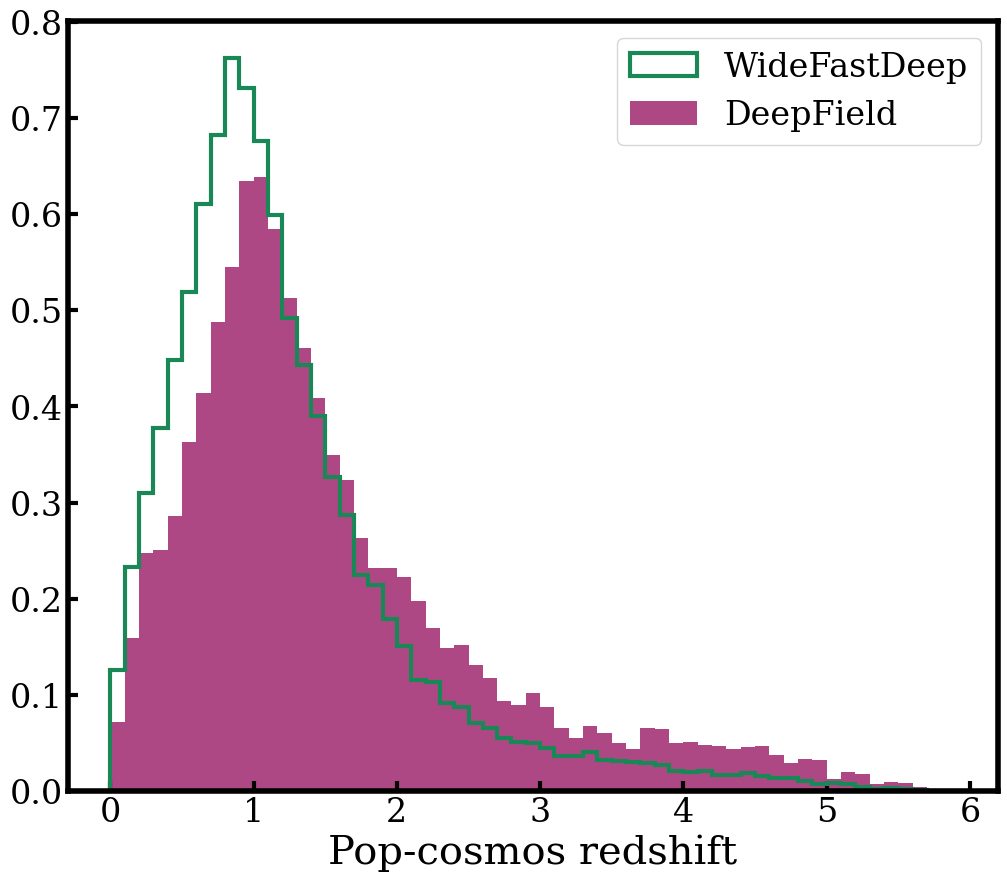

In [177]:
fig = plt.figure()
ax = fig.add_subplot()

bins = np.arange(0, 6, 0.1)
ax.hist(REDSHIFTS_WideFastDeep, bins = bins, histtype = "step", linewidth = 3, label = "WideFastDeep", density = True)
ax.hist(REDSHIFTS_DeepField, bins = bins, label = "DeepField", density = True)

ax.legend(frameon = "False")
ax.set_xlabel("Pop-cosmos redshift")

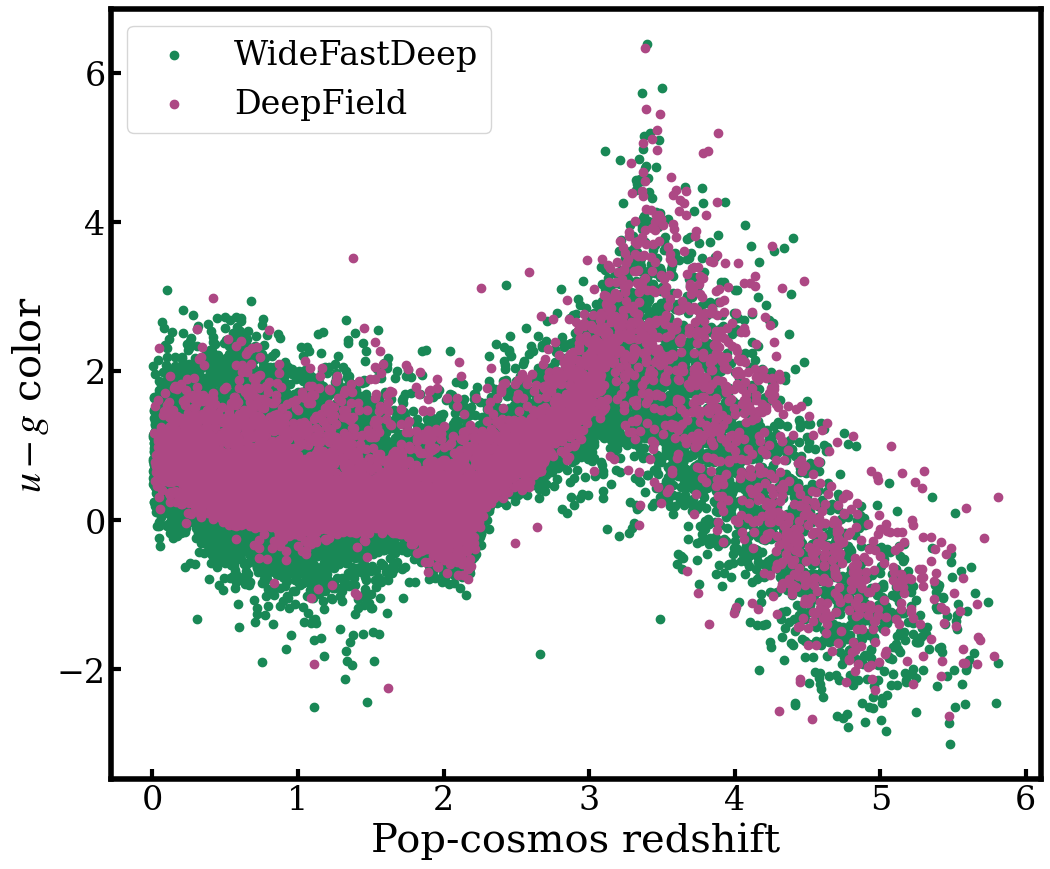

In [178]:
fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(REDSHIFTS_WideFastDeep, PHOTOMETRY_WideFastDeep_noisy["LSST_u"] - PHOTOMETRY_WideFastDeep_noisy["LSST_g"], label = "WideFastDeep")
ax.scatter(REDSHIFTS_DeepField, PHOTOMETRY_DeepField_noisy["LSST_u"] - PHOTOMETRY_DeepField_noisy["LSST_g"], label = "DeepField")

ax.set_xlabel("Pop-cosmos redshift")
ax.set_ylabel("$u-g$ color")
ax.legend()

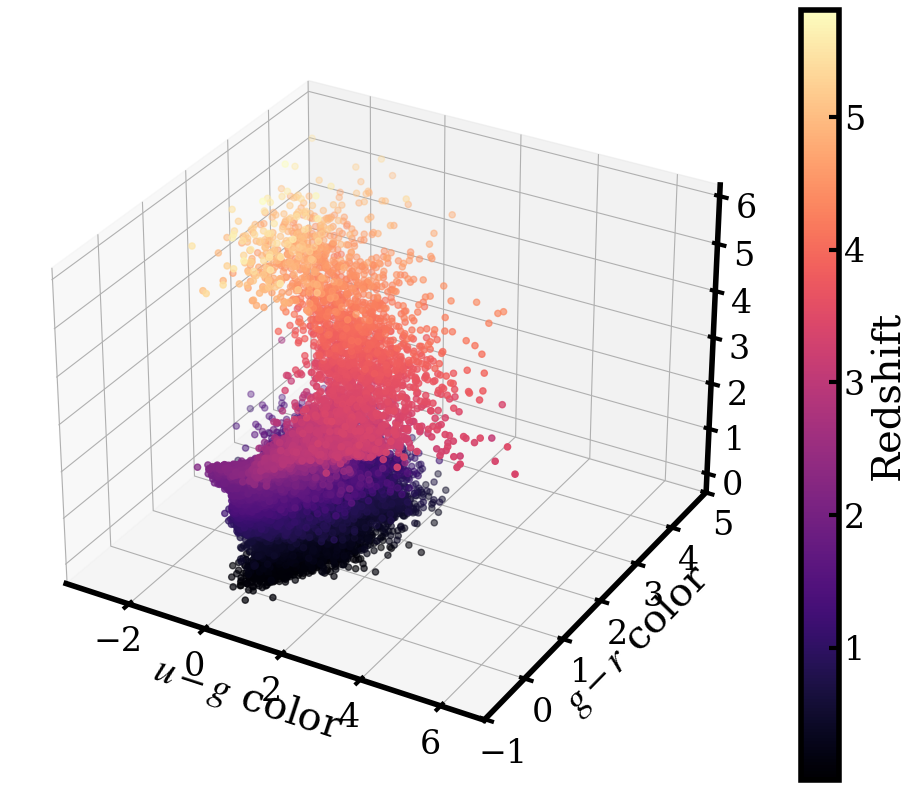

: 

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection = "3d")

scatter = ax.scatter(PHOTOMETRY_WideFastDeep_noisy["LSST_u"] - PHOTOMETRY_WideFastDeep_noisy["LSST_g"],
           PHOTOMETRY_WideFastDeep_noisy["LSST_g"] - PHOTOMETRY_WideFastDeep_noisy["LSST_r"],
           REDSHIFTS_WideFastDeep, c = REDSHIFTS_WideFastDeep)

ax.set_xlabel("$u-g$ color")
ax.set_ylabel("$g-r$ color")
fig.colorbar(mappable = scatter, label = "Redshift")

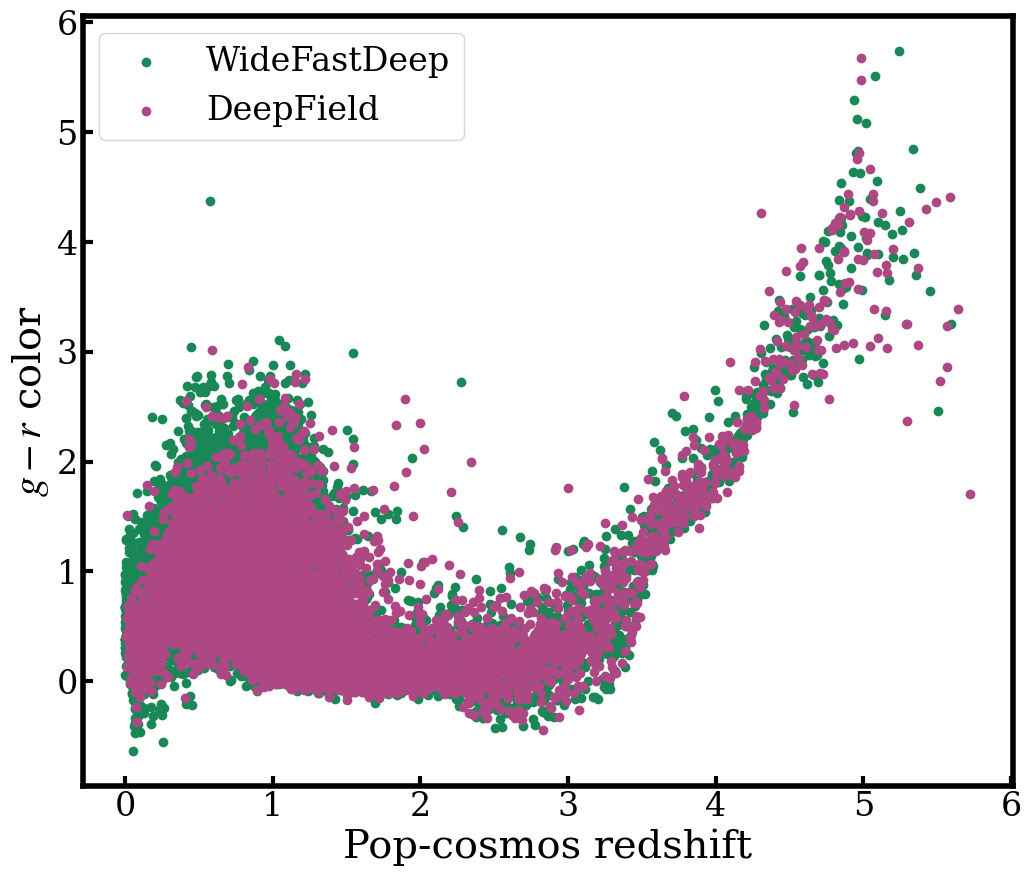

In [165]:
fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(REDSHIFTS_WideFastDeep, PHOTOMETRY_WideFastDeep_noisy["LSST_g"] - PHOTOMETRY_WideFastDeep_noisy["LSST_r"], label = "WideFastDeep")
ax.scatter(REDSHIFTS_DeepField, PHOTOMETRY_DeepField_noisy["LSST_g"] - PHOTOMETRY_DeepField_noisy["LSST_r"], label = "DeepField")

ax.set_xlabel("Pop-cosmos redshift")
ax.set_ylabel("$g-r$ color")
ax.legend()

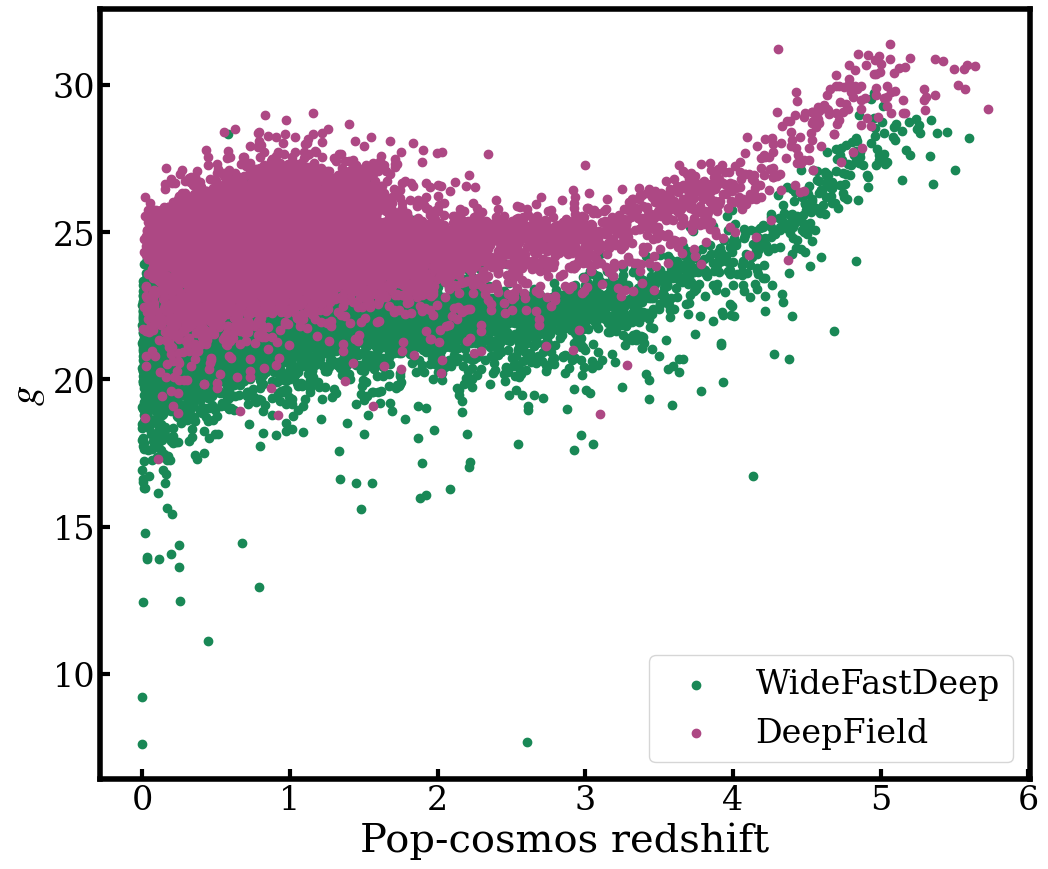

In [172]:
fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(REDSHIFTS_WideFastDeep, PHOTOMETRY_WideFastDeep_noisy["LSST_g"], label = "WideFastDeep")
ax.scatter(REDSHIFTS_DeepField, PHOTOMETRY_DeepField_noisy["LSST_g"], label = "DeepField")

ax.set_xlabel("Pop-cosmos redshift")
ax.set_ylabel("$g$ ")
ax.legend()

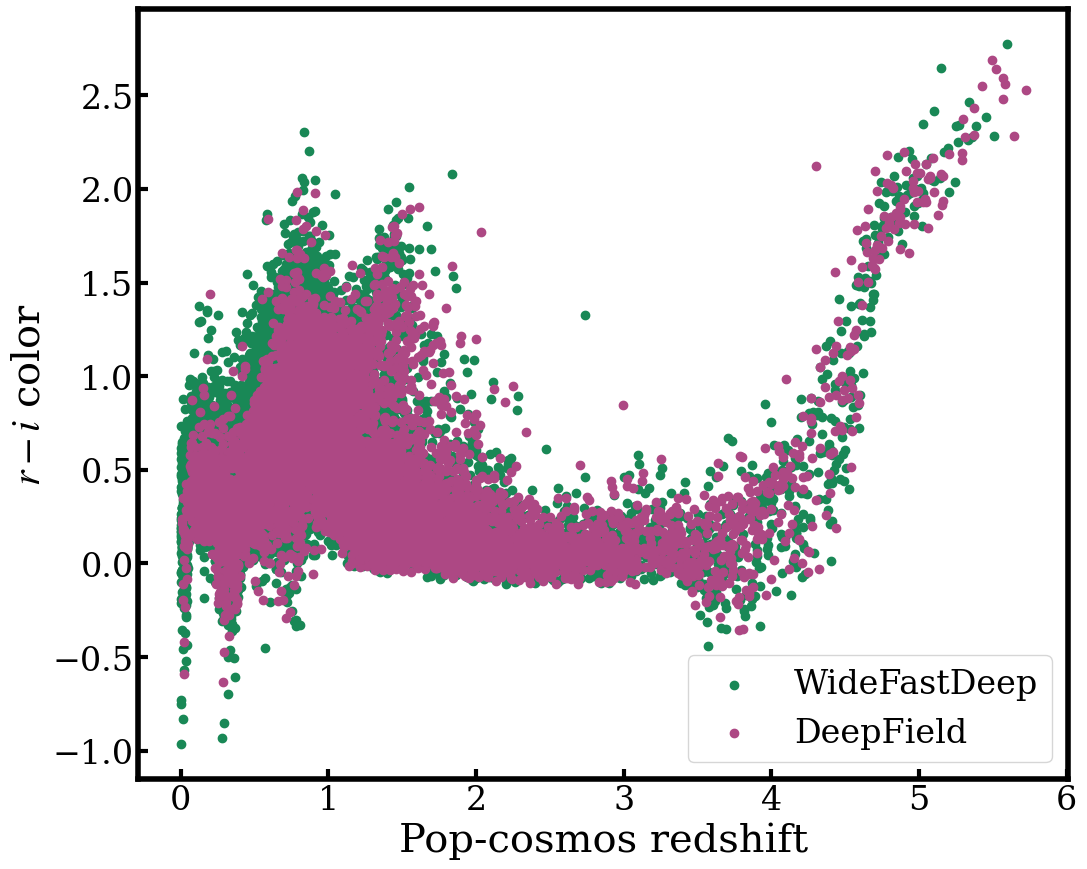

In [166]:
fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(REDSHIFTS_WideFastDeep, PHOTOMETRY_WideFastDeep_noisy["LSST_r"] - PHOTOMETRY_WideFastDeep_noisy["LSST_i"], label = "WideFastDeep")
ax.scatter(REDSHIFTS_DeepField, PHOTOMETRY_DeepField_noisy["LSST_r"] - PHOTOMETRY_DeepField_noisy["LSST_i"], label = "DeepField")

ax.set_xlabel("Pop-cosmos redshift")
ax.set_ylabel("$r-i$ color")
ax.legend()

In [141]:


# np.save(f"{outputs_directory}/TRUEREDSHIFTS_DeepField",             REDSHIFTS_DeepField,             allow_pickle = True)            
# np.save(f"{outputs_directory}/TRUEREDSHIFTS_DeepField_lpReference", REDSHIFTS_DeepField_lpReference, allow_pickle = True)
# np.save(f"{outputs_directory}/TRUEREDSHIFTS_WideFastDeep",          REDSHIFTS_WideFastDeep,          allow_pickle = True)         

print(timestamp(), "Finished creating datasets. Time elapsed: ", timer(start_time))

print("------------ Length of datasets ------------")
print(f"Deep field:                    {len(PHOTOMETRY_DeepField_noisy)}")
print(f"Deep field, LePhare reference: {len(PHOTOMETRY_DeepField_noisy_lpReference)}")
print(f"WideFastDeep field:            {len(PHOTOMETRY_WideFastDeep_noisy)}")
print("--------------------------------------------")


[15:02:08] Finished creating datasets. Time elapsed:  47m 45.0s
------------ Length of datasets ------------
Deep field:                    10000
Deep field, LePhare reference: 10000
WideFastDeep field:            50000
--------------------------------------------


(array([0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 3.000e+00,
        2.000e+00, 5.000e+00, 6.000e+00, 1.500e+01, 3.400e+01, 7.400e+01,
        1.360e+02, 2.890e+02, 4.600e+02, 9.520e+02, 1.911e+03, 3.551e+03,
        5.731e+03, 8.409e+03, 9.145e+03, 7.176e+03, 4.869e+03, 3.394e+03,
        2.322e+03, 1.193e+03, 2.990e+02, 2.100e+01, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00]),
 array([ 0. ,  0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,
         5.5,  6. ,  6.5,  7. ,  7.5,  8. ,  8.5,  9. ,  9.5, 10. , 10.5,
        11. , 11.5, 12. , 12.5, 13. , 13.5, 14. , 14.5, 15. , 15.5, 1

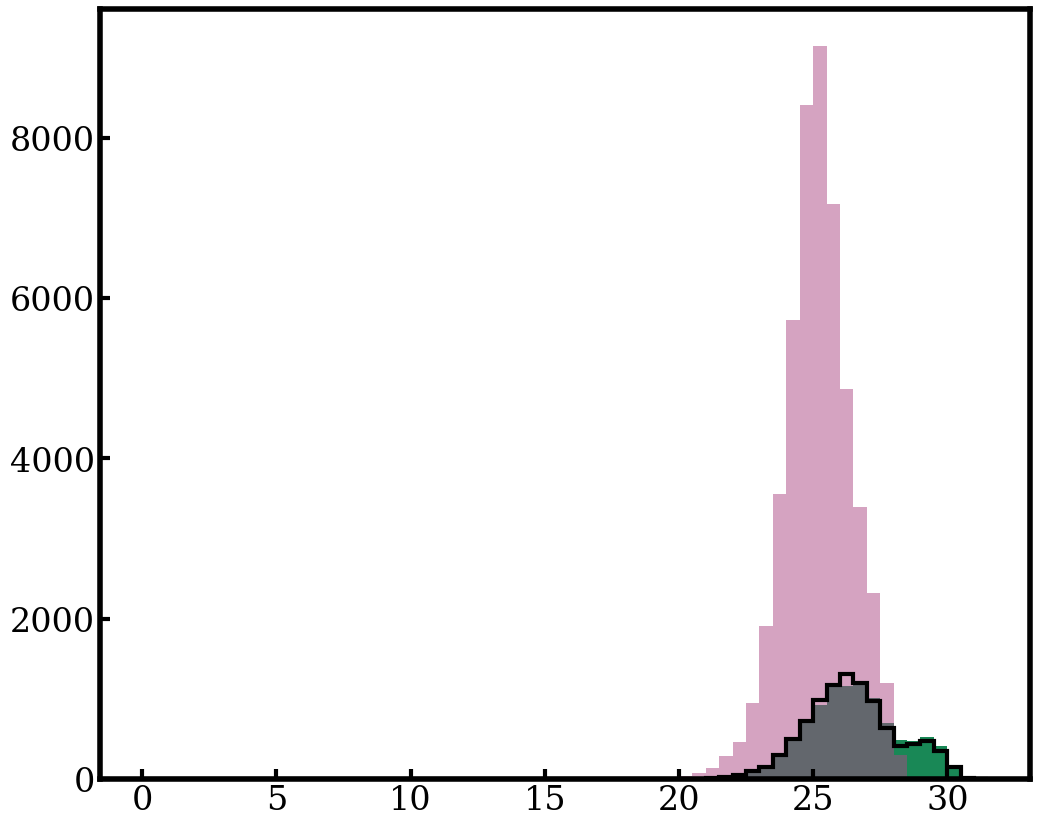

In [120]:
fig = plt.figure()
ax = fig.add_subplot()

bins = np.arange(0, 32, 0.5)

band = "LSST_u"
ax.hist(PHOTOMETRY_DeepField_noisy[band], bins = bins)
ax.hist(PHOTOMETRY_DeepField_noisy_lpReference[band], bins = bins,
        histtype = "step", linewidth = 3, color = "black")
ax.hist(PHOTOMETRY_WideFastDeep_noisy[band], bins = bins,
        alpha = 0.5)

In [ ]:
TRAININGDATA_LePhare = PHOTOMETRY_DeepField_noisy_lpReference.copy()
TRAININGDATA_LePhare["redshift"] = REDSHIFTS_DeepField_lpReferenceb
T

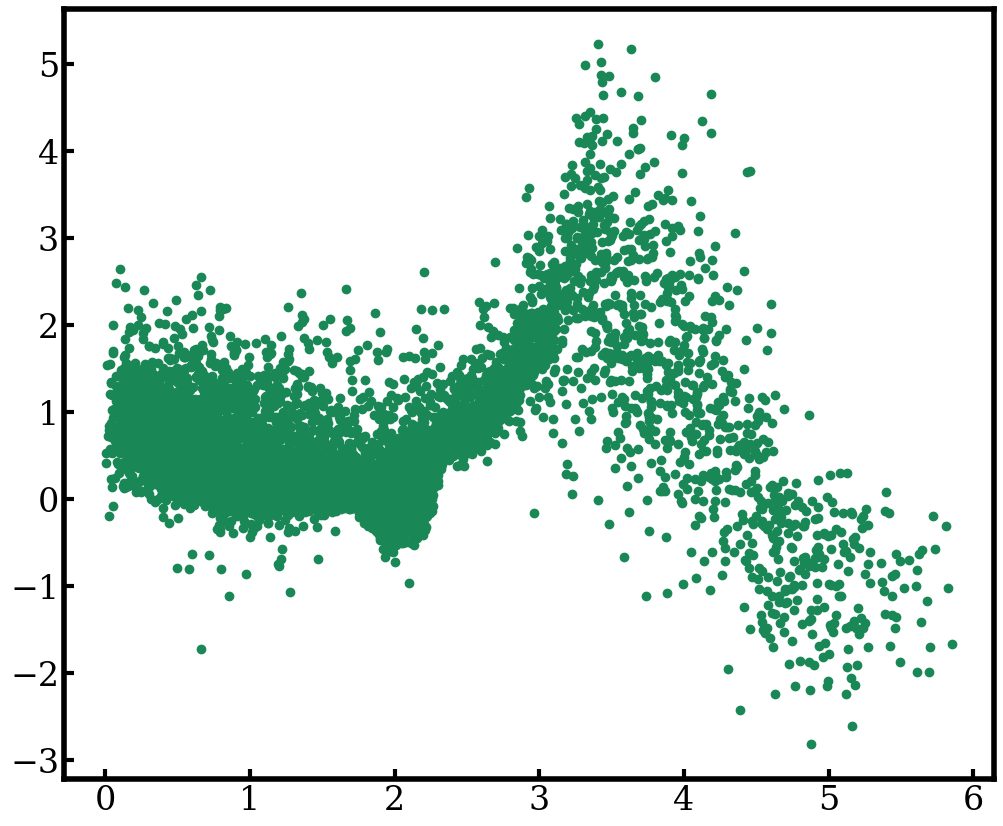

In [146]:
fig = plt.figure()
ax = fig.add_subplot()

bins = np.arange(0, 6, 0.1)
ax.scatter(TRAININGDATA_LePhare["redshift"],
           TRAININGDATA_LePhare["LSST_u"] - TRAININGDATA_LePhare["LSST_g"])

In [ ]:


# ----------------------------------------------------------------------------------------------- #
# Section 2: Estimate photo-zs for deep-field sampe with LePhare                                  #
# ----------------------------------------------------------------------------------------------- #

print(timestamp(), "Informing LePhare", end = "\r")

### Inform LePhare
outputModelPath_lePhare = f"{outputs_directory}/model_lephare_{date}.pkl"

inform_lephare = LephareInformer.make_stage(
    
    name           = "inform_lephare",

    nondetect_val  = np.nan,
    model          = outputModelPath_lePhare,
    hdf5_groupname = "",
    
    bands        = BANDS_DeepField,
    err_bands    = ERR_BANDS_DeepField,
    ref_band     = "LSST_i",
    redshift_col = "redshift",
    
    zmin   = 0,
    zmax   = 6,
    nzbins = 601,
    
    **{
        "lephare.FILTER_LIST": FILTER_LIST,
        "lephare.FILTER_FILE": "filter_pipeline",
    },
)

TRAININGDATA_LePhare = PHOTOMETRY_DeepField_noisy_lpReference.copy()
TRAININGDATA_LePhare["redshift"] = REDSHIFTS_DeepField_lpReference

inform_lephare.inform(TRAININGDATA_LePhare)
inform_lephare.get_handle("model").write()
inform_lephare.finalize()

print(timestamp(), "Informed LePhare. Time elapsed: ", timer(start_time))

print(timestamp(), "Estimating photo-zs with LePhare", end = "\r")

### Estimate with LePhare
outputEstimationPath_lePhare = f"{outputs_directory}/estimation_lephare_{date}"
estimate_lephare = LephareEstimator.make_stage(
    
    name           = "estimate_lephare",
    model          = inform_lephare.get_handle("model"),
    hdf5_groupname = "",

    bands        = BANDS_DeepField,
    err_bands    = ERR_BANDS_DeepField,
    ref_band     = "LSST_i",
    
    nondetect_val = np.nan,
    aliases = dict(input="test_data", output="lephare_estim"),
)

ESTIMATION_DATA_LePhare = getNoisyDeepFieldPhotometry.get_handle("noisy_catalog").data
lephare_estimated = estimate_lephare.estimate(ESTIMATION_DATA_LePhare)

PHOTOZS_rawLePhareOutput = lephare_estimated.read().median()
SIGMAS_photoZs_rawLePhareOutput = lephare_estimated.read().std()
PHOTOZS_DeepField_lephare = np.reshape(PHOTOZS_rawLePhareOutput, len(PHOTOZS_rawLePhareOutput))
SIGMAS_photozs_DeepField_lephare = np.reshape(SIGMAS_photoZs_rawLePhareOutput, len(SIGMAS_photoZs_rawLePhareOutput))

df_PHOTOZS_DeepField_lephare = pd.DataFrame({"photo-z": PHOTOZS_DeepField_lephare, "sigma-photo-z": SIGMAS_photozs_DeepField_lephare})
df_PHOTOZS_DeepField_lephare.to_parquet(f"{outputs_directory}/PHOTOZS_DeepField_lePhare_{date}.pq")

print(timestamp(), "Finished estimating photo-zs with LePhare. Time elapsed: ", timer(start_time))

# ----------------------------------------------------------------------------------------------- #
# Section 3: Estimate redshfits with UMAPs                                                        #
# ----------------------------------------------------------------------------------------------- #

print(timestamp(), "Preparing input data for UMAPs", end = "\r")

### Prepare input data
TRAINING_DATA_UMAP = getNoisyDeepFieldPhotometry.get_handle("noisy_catalog").data

TRAINING_PHOTOMETRY_UMAP = TRAINING_DATA_UMAP[BANDS_WideFastDeep]
TRAINING_PHOTOMERRS_UMAP = TRAINING_DATA_UMAP[ERR_BANDS_WideFastDeep]

TRAINING_REDSHIFTS_UMAP_specZs  = REDSHIFTS_DeepField
TRAINING_REDSHIFTS_UMAP_photoZs = PHOTOZS_DeepField_lephare

ESTIMATION_DATA_UMAP = getNoisyWideFastDeepPhotometry.get_handle("noisy_catalog").data

ESTIMATION_PHOTOMETRY_UMAP = ESTIMATION_DATA_UMAP[BANDS_WideFastDeep]
ESTIMATION_PHOTOMERRS_UMAP = ESTIMATION_DATA_UMAP[ERR_BANDS_WideFastDeep]

COLORNAMES_WideFastDeep = [f"{BANDS_WideFastDeep[i].split('_')[-1]}-{BANDS_WideFastDeep[i + 1].split('_')[-1]}"
                           for i in range(len(BANDS_WideFastDeep) - 1)]

COLERRNAMES_WideFastDeep = [f"{BANDS_WideFastDeep[i].split('_')[-1]}-{BANDS_WideFastDeep[i + 1].split('_')[-1]}_err"
                           for i in range(len(BANDS_WideFastDeep) - 1)]

TRAINING_COLORS_UMAP = pd.DataFrame(
    {COLORNAMES_WideFastDeep[i]:
        TRAINING_PHOTOMETRY_UMAP[BANDS_WideFastDeep[i]] - TRAINING_PHOTOMETRY_UMAP[BANDS_WideFastDeep[i + 1]]
            for i in range(len(BANDS_WideFastDeep) - 1)}
)

TRAINING_COLERRS_UMAP = pd.DataFrame(
    {COLERRNAMES_WideFastDeep[i]:
        np.clip(np.sqrt(TRAINING_PHOTOMERRS_UMAP[ERR_BANDS_WideFastDeep[i]]**2 + TRAINING_PHOTOMERRS_UMAP[ERR_BANDS_WideFastDeep[i + 1]]**2),
                None, 0.05)
            for i in range(len(ERR_BANDS_WideFastDeep) - 1)}
)

ESTIMATION_COLORS_UMAP = pd.DataFrame(
    {COLORNAMES_WideFastDeep[i]:
        ESTIMATION_PHOTOMETRY_UMAP[BANDS_WideFastDeep[i]] - ESTIMATION_PHOTOMETRY_UMAP[BANDS_WideFastDeep[i + 1]]
            for i in range(len(BANDS_WideFastDeep) - 1)}
)

ESTIMATION_COLERRS_UMAP = pd.DataFrame(
    {COLERRNAMES_WideFastDeep[i]:
        np.clip(np.sqrt(ESTIMATION_PHOTOMERRS_UMAP[ERR_BANDS_WideFastDeep[i]]**2 + ESTIMATION_PHOTOMERRS_UMAP[ERR_BANDS_WideFastDeep[i + 1]]**2),
                None, 0.05)
            for i in range(len(ERR_BANDS_WideFastDeep) - 1)}
)

TRAINING_COLORS_UMAP.to_parquet(f"{outputs_directory}/TRAINING_COLORS_UMAP{date}.pq")
TRAINING_COLERRS_UMAP.to_parquet(f"{outputs_directory}/TRAINING_COLERRS_UMAP{date}.pq")
ESTIMATION_COLORS_UMAP.to_parquet(f"{outputs_directory}/ESTIMATION_COLORS_UMAP{date}.pq")
ESTIMATION_COLERRS_UMAP.to_parquet(f"{outputs_directory}/ESTIMATION_COLERRS_UMAP{date}.pq")

print(timestamp(), "Prepared input data for UMAPs. Time elapsed: ", timer(start_time))

print(timestamp(), "Building, and getting redshifts from, spec-z UMAP", end = "\r")

### Set UMAP parameters
ambient_metric_umap = "manhattan_weighted_linear"
n_neighbors_umap    = 80
min_dist            = 0.0

n_neighbors_knn = 100
metric_p_knn   = 2

precision_gauss_kde = 0.01

### Buld a UMAP from the training photometry, colored with spectrosopic redshifts
informedReducerPath_UMAP_wSpecZs      = f"{outputs_directory}/informedReducer_UMAP_wSpecZs_{date}.pkl"
informedEmbeddingPath_UMAP_wSpecZs    = f"{outputs_directory}/informedEmbedding_UMAP_wSpecZs_{date}.pq"
informedkNNRegressorPath_UMAP_wSpecZs = f"{outputs_directory}/informedkNNRegressor_UMAP_wSpecZs_{date}.pkl"

estimatedEmbeddingPath_UMAP_wSpecZs     = f"{outputs_directory}/estimatedEmbedding_UMAP_wSpecZs_{date}.pq"
estimatedPhotoZMediansPath_UMAP_wSpecZs = f"{outputs_directory}/estimatedPhotoZMedians_UMAP_wSpecZs_{date}.pq"
estimatedPhotoZPDFsPath_UMAP_wSpecZs    = f"{outputs_directory}/estimatedPhotoZPDFs_UMAP_wSpecZs_{date}.hdf5"

estimatePhotozsUMAP_wSpecZs = UMAPEstimator.make_stage(
    name = "estimatePhotozsUMAP_wSpecZs",

    ### Specify paths
    informed_reducer       = informedReducerPath_UMAP_wSpecZs,
    informed_embedding     = informedEmbeddingPath_UMAP_wSpecZs,
    informed_kNN_regressor = informedkNNRegressorPath_UMAP_wSpecZs,

    estimated_embedding      = estimatedEmbeddingPath_UMAP_wSpecZs,
    estimated_photoz_medians = estimatedPhotoZMediansPath_UMAP_wSpecZs,
    estimated_photoz_pdfs    = estimatedPhotoZPDFsPath_UMAP_wSpecZs,

    ### Specify UMAP parameters
    ambient_metric_umap = ambient_metric_umap,
    
    n_neighbors_umap = n_neighbors_umap,
    min_dist         = min_dist,
    
    n_neighbors_knn = n_neighbors_knn,
    metric_p_knn    = metric_p_knn,
    
    precision_gauss_kde = precision_gauss_kde,
    
    seed = seed
)

estimatePhotozsUMAP_wSpecZs.set_data("training_photometry", data = TRAINING_COLORS_UMAP)
estimatePhotozsUMAP_wSpecZs.set_data("training_phot_error", data = TRAINING_COLERRS_UMAP)
estimatePhotozsUMAP_wSpecZs.set_data("training_redshift",   data = TRAINING_REDSHIFTS_UMAP_specZs)

estimatePhotozsUMAP_wSpecZs.UMAP_informer()

estimatePhotozsUMAP_wSpecZs.set_data("estimation_photometry", data = ESTIMATION_COLORS_UMAP)
estimatePhotozsUMAP_wSpecZs.set_data("estimation_phot_error", data = ESTIMATION_COLERRS_UMAP)
estimatePhotozsUMAP_wSpecZs.UMAP_estimator()

estimatePhotozsUMAP_wSpecZs.get_handle("informed_reducer").write()
estimatePhotozsUMAP_wSpecZs.get_handle("informed_embedding").write()
estimatePhotozsUMAP_wSpecZs.get_handle("informed_kNN_regressor").write()
estimatePhotozsUMAP_wSpecZs.get_handle("estimated_embedding").write()
estimatePhotozsUMAP_wSpecZs.get_handle("estimated_photoz_medians").write()
estimatePhotozsUMAP_wSpecZs.get_handle("estimated_photoz_pdfs").write()

PHOTOZS_estimated_wSpecZs = estimatePhotozsUMAP_wSpecZs.get_handle("estimated_photoz_medians").data
estimatePhotozsUMAP_wSpecZs.finalize()

print(timestamp(), "Built, and got photo-zs from, spec-z UMAP. Time elapsed: ", timer(start_time))

print(timestamp(), "Building, and getting redshifts from, photoz-z UMAP", end = "\r")

### Buld a UMAP from the training photometry, colored with the photometric redshifts from LePhare
informedReducerPath_UMAP_wPhotoZs      = f"{outputs_directory}/informedReducer_UMAP_wPhotoZs_{date}.pkl"
informedEmbeddingPath_UMAP_wPhotoZs    = f"{outputs_directory}/informedEmbedding_UMAP_wPhotoZs_{date}.pq"
informedkNNRegressorPath_UMAP_wPhotoZs = f"{outputs_directory}/informedkNNRegressor_UMAP_wPhotoZs_{date}.pkl"

estimatedEmbeddingPath_UMAP_wPhotoZs     = f"{outputs_directory}/estimatedEmbedding_UMAP_wPhotoZs_{date}.pq"
estimatedPhotoZMediansPath_UMAP_wPhotoZs = f"{outputs_directory}/estimatedPhotoZMedians_UMAP_wPhotoZs_{date}.pq"
estimatedPhotoZPDFsPath_UMAP_wPhotoZs    = f"{outputs_directory}/estimatedPhotoZPDFs_UMAP_wPhotoZs_{date}.hdf5"

estimatePhotozsUMAP_wPhotoZs = UMAPEstimator.make_stage(
    name = "estimatePhotozsUMAP_wPhotoZs",

    ### Specify paths
    informed_reducer       = informedReducerPath_UMAP_wPhotoZs,
    informed_embedding     = informedEmbeddingPath_UMAP_wPhotoZs,
    informed_kNN_regressor = informedkNNRegressorPath_UMAP_wPhotoZs,

    estimated_embedding      = estimatedEmbeddingPath_UMAP_wPhotoZs,
    estimated_photoz_medians = estimatedPhotoZMediansPath_UMAP_wPhotoZs,
    estimated_photoz_pdfs    = estimatedPhotoZPDFsPath_UMAP_wPhotoZs,

    ### Specify UMAP parameters
    ambient_metric_umap = ambient_metric_umap,
    
    n_neighbors_umap = n_neighbors_umap,
    min_dist         = min_dist,
    
    n_neighbors_knn = n_neighbors_knn,
    metric_p_knn    = metric_p_knn,
    
    precision_gauss_kde = precision_gauss_kde,
    
    seed = seed
)

estimatePhotozsUMAP_wPhotoZs.set_data("training_photometry", data = TRAINING_PHOTOMETRY_UMAP)
estimatePhotozsUMAP_wPhotoZs.set_data("training_phot_error", data = TRAINING_PHOTOMERRS_UMAP)
estimatePhotozsUMAP_wPhotoZs.set_data("training_redshift",   data = TRAINING_REDSHIFTS_UMAP_photoZs)

estimatePhotozsUMAP_wPhotoZs.UMAP_informer()

estimatePhotozsUMAP_wPhotoZs.set_data("estimation_photometry", data = ESTIMATION_PHOTOMETRY_UMAP)
estimatePhotozsUMAP_wPhotoZs.set_data("estimation_phot_error", data = ESTIMATION_PHOTOMERRS_UMAP)
estimatePhotozsUMAP_wPhotoZs.UMAP_estimator()

estimatePhotozsUMAP_wPhotoZs.get_handle("informed_reducer").write()
estimatePhotozsUMAP_wPhotoZs.get_handle("informed_embedding").write()
estimatePhotozsUMAP_wPhotoZs.get_handle("informed_kNN_regressor").write()
estimatePhotozsUMAP_wPhotoZs.get_handle("estimated_embedding").write()
estimatePhotozsUMAP_wPhotoZs.get_handle("estimated_photoz_medians").write()
estimatePhotozsUMAP_wPhotoZs.get_handle("estimated_photoz_pdfs").write()

PHOTOZS_estimated_wPhotoZs = estimatePhotozsUMAP_wPhotoZs.get_handle("estimated_photoz_medians").data
estimatePhotozsUMAP_wPhotoZs.finalize()

print(timestamp(), "Built, and got photo-zs from, photo-z UMAP. Time elapsed: ", timer(start_time))

print("Pipeline finished.")

In [1]:
import numpy as np
import tables_io

import matplotlib.pyplot as plt
plt.style.use("/global/homes/s/sajkov/umap_nz_cal.mplstyle")

In [31]:

noiseless_catalog_filepath = "/pscratch/sd/s/sajkov/data/integrated_catalog_23apr26.pq"
redshifts_filepath = "/pscratch/sd/s/sajkov/data/mock_catalog_Ch1_26.h5"

DATASET_popCosmos_full   = tables_io.read(noiseless_catalog_filepath)

column_list None


In [34]:
DATASET_popCosmos_full[["HSC_MB_00", "HSC_MB_01", "Roman_F146"]].iloc[:100]

,HSC_MB_00,HSC_MB_01,Roman_F146
index,,,
0,26.646777,26.631146,25.872446
1,25.478313,25.444676,24.259548
2,25.979943,25.638787,19.880483
3,42.046864,41.387407,27.139340
4,26.811081,26.876659,25.835978
...,...,...,...
95,24.743691,24.570299,22.273644
96,25.563383,25.521383,24.554852
97,24.728293,24.680830,23.456048


# Load files

In [3]:
directory = "/pscratch/sd/s/sajkov/analysis_pipeline/runs/08Jul26"

In [4]:
PHOTOMETRY_DeepField_noisy    = tables_io.read(f"{directory}/PHOTOMETRY_DeepField_noisy_08Jul26.pq")
PHOTOMETRY_DeepField_noisy_lpReference    = tables_io.read(f"{directory}/PHOTOMETRY_DeepField_noisy_lpReference_08Jul26.pq")
PHOTOMETRY_WideFastDeep_noisy = tables_io.read(f"{directory}/PHOTOMETRY_WideFastDeep_noisy_08Jul26.pq")
PHOTOZS_DeepField_lePhare     = tables_io.read(f"{directory}/PHOTOZS_DeepField_lePhare_08Jul26.pq")['photo-z']
REDSHIFTS_DeepField           = np.load(f"{directory}/TRUEREDSHIFTS_DeepField.npy")

column_list None
column_list None
column_list None
column_list None


# Check impact of having no $i$-band cut

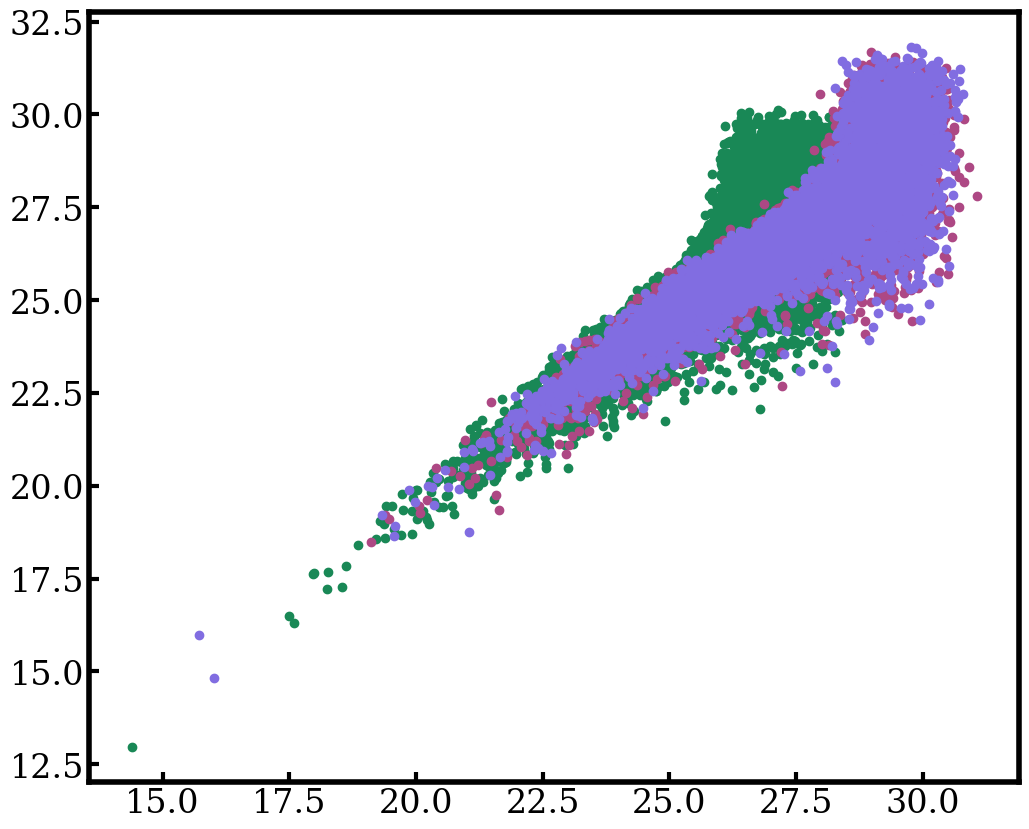

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(PHOTOMETRY_WideFastDeep_noisy["LSST_u"], PHOTOMETRY_WideFastDeep_noisy["LSST_g"], label = "WideFastDeep")
ax.scatter(PHOTOMETRY_DeepField_noisy_lpReference["LSST_u"], PHOTOMETRY_DeepField_noisy_lpReference["LSST_g"], label = "")
ax.scatter(PHOTOMETRY_DeepField_noisy["LSST_u"], PHOTOMETRY_DeepField_noisy["LSST_g"])

ax.set_xlabel("$u$ mag")
ax.set_ylabel("$g$ mag")

ax.legend()

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

ax.scatter(PHOTOMETRY_WideFastDeep_noisy["LSST_g"], PHOTOMETRY_WideFastDeep_noisy["LSST_g"])
ax.scatter(PHOTOMETRY_DeepField_noisy_lpReference["LSST_g"], PHOTOMETRY_DeepField_noisy_lpReference["LSST_g"])
ax.scatter(PHOTOMETRY_DeepField_noisy["LSST_g"], PHOTOMETRY_DeepField_noisy["LSST_g"])

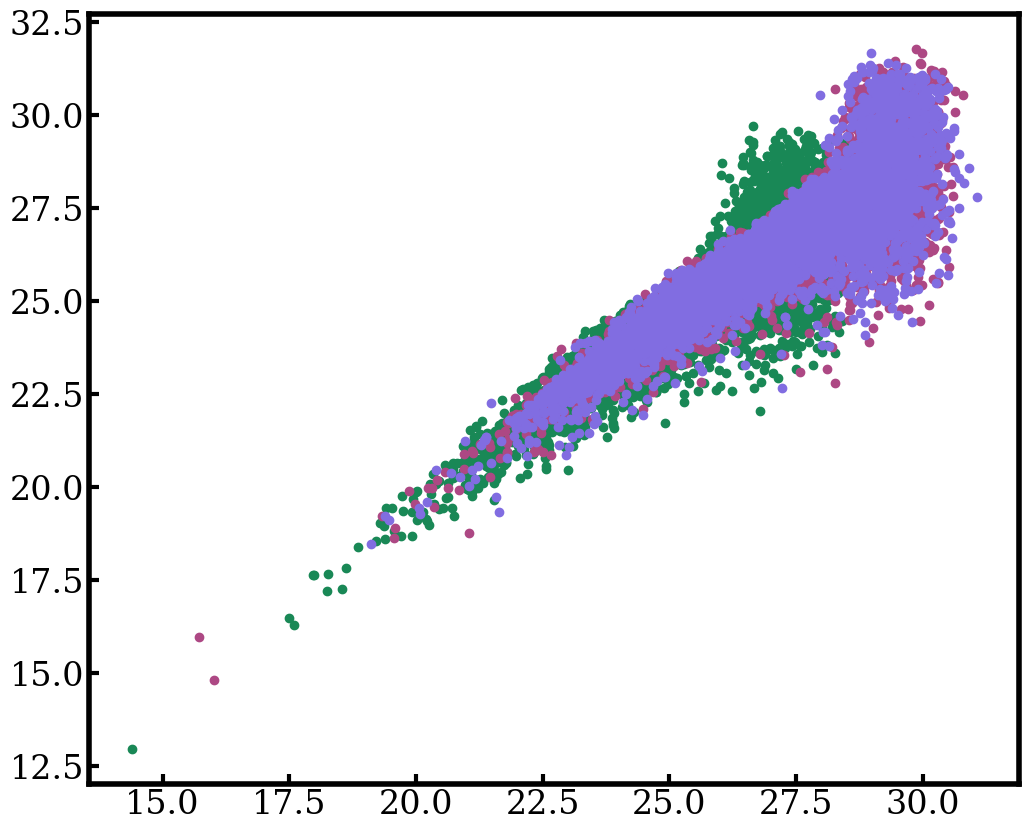

In [8]:
fig = plt.figure()
ax = fig.add_subplot()

iBandLimit_DeepField    = 27.5
iBandLimit_WideFastDeep = 25

ax.scatter(PHOTOMETRY_WideFastDeep_noisy[PHOTOMETRY_WideFastDeep_noisy["LSST_i"] < iBandLimit_WideFastDeep]["LSST_u"],
           PHOTOMETRY_WideFastDeep_noisy[PHOTOMETRY_WideFastDeep_noisy["LSST_i"] < iBandLimit_WideFastDeep]["LSST_g"])

ax.scatter(PHOTOMETRY_DeepField_noisy[PHOTOMETRY_DeepField_noisy["LSST_i"] < iBandLimit_DeepField]["LSST_u"],
           PHOTOMETRY_DeepField_noisy[PHOTOMETRY_DeepField_noisy["LSST_i"] < iBandLimit_DeepField]["LSST_g"])

ax.scatter(PHOTOMETRY_DeepField_noisy_lpReference[PHOTOMETRY_DeepField_noisy_lpReference["LSST_i"] < iBandLimit_DeepField]["LSST_u"],
           PHOTOMETRY_DeepField_noisy_lpReference[PHOTOMETRY_DeepField_noisy_lpReference["LSST_i"] < iBandLimit_DeepField]["LSST_g"])

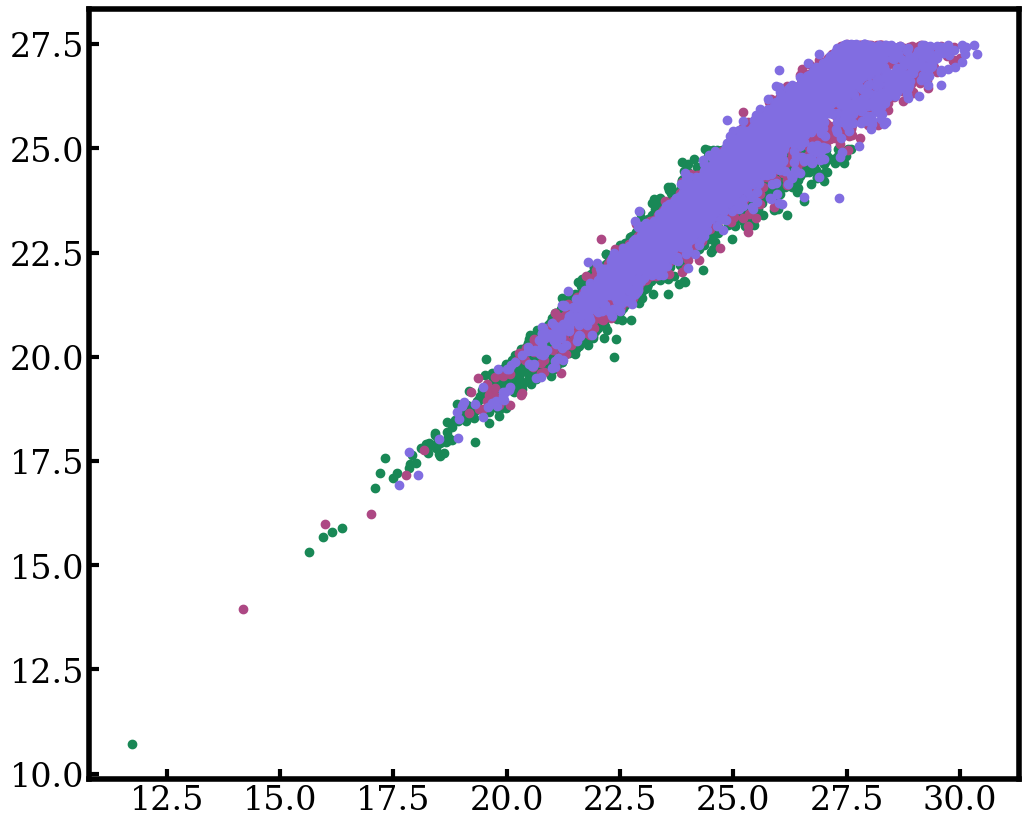

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()

iBandLimit_DeepField    = 27.5
iBandLimit_WideFastDeep = 25

ax.scatter(PHOTOMETRY_WideFastDeep_noisy[PHOTOMETRY_WideFastDeep_noisy["LSST_i"] < iBandLimit_WideFastDeep]["LSST_r"],
           PHOTOMETRY_WideFastDeep_noisy[PHOTOMETRY_WideFastDeep_noisy["LSST_i"] < iBandLimit_WideFastDeep]["LSST_i"])

ax.scatter(PHOTOMETRY_DeepField_noisy[PHOTOMETRY_DeepField_noisy["LSST_i"] < iBandLimit_DeepField]["LSST_r"],
           PHOTOMETRY_DeepField_noisy[PHOTOMETRY_DeepField_noisy["LSST_i"] < iBandLimit_DeepField]["LSST_i"])

ax.scatter(PHOTOMETRY_DeepField_noisy_lpReference[PHOTOMETRY_DeepField_noisy_lpReference["LSST_i"] < iBandLimit_DeepField]["LSST_r"],
           PHOTOMETRY_DeepField_noisy_lpReference[PHOTOMETRY_DeepField_noisy_lpReference["LSST_i"] < iBandLimit_DeepField]["LSST_i"])

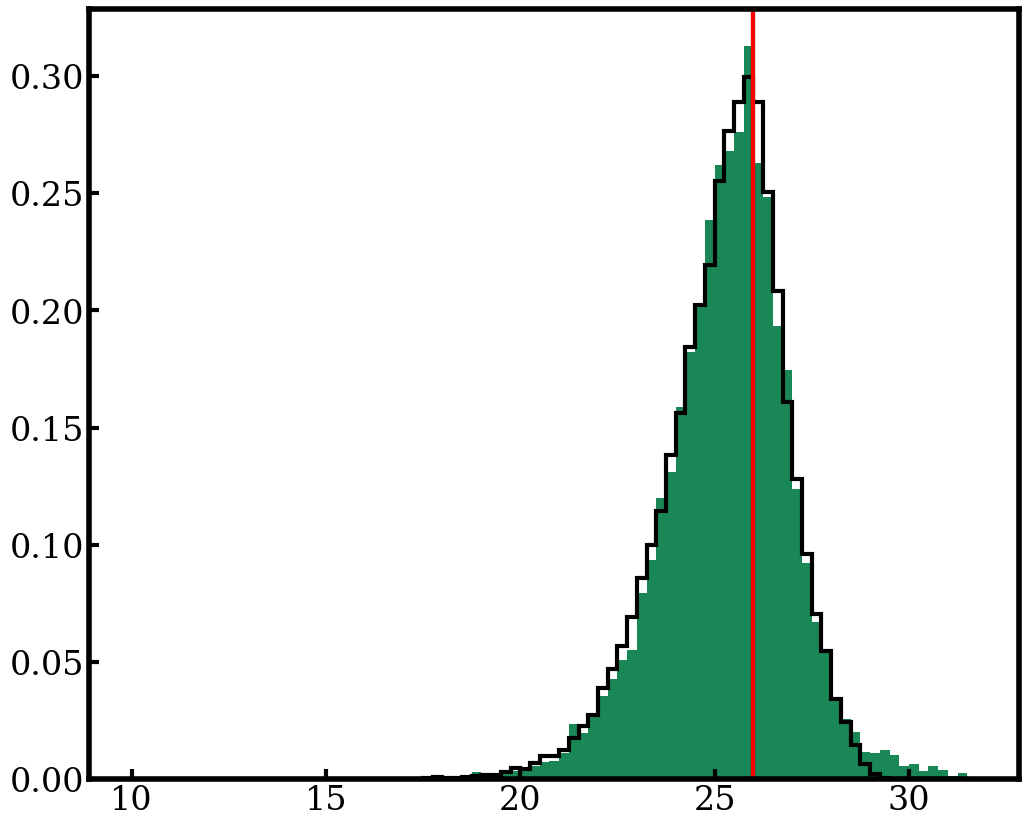

In [25]:
fig = plt.figure()
ax = fig.add_subplot()

bins = np.arange(10, 32, 0.25)
ax.hist(PHOTOMETRY_DeepField_noisy_lpReference["LSST_i"], bins = bins, density = True)
ax.axvline(26, color = "black")

ax.hist(PHOTOMETRY_WideFastDeep_noisy["LSST_i"], bins = bins, histtype = 'step', density = True,
        linewidth = 3, color = "black")
ax.axvline(26, color = "red")

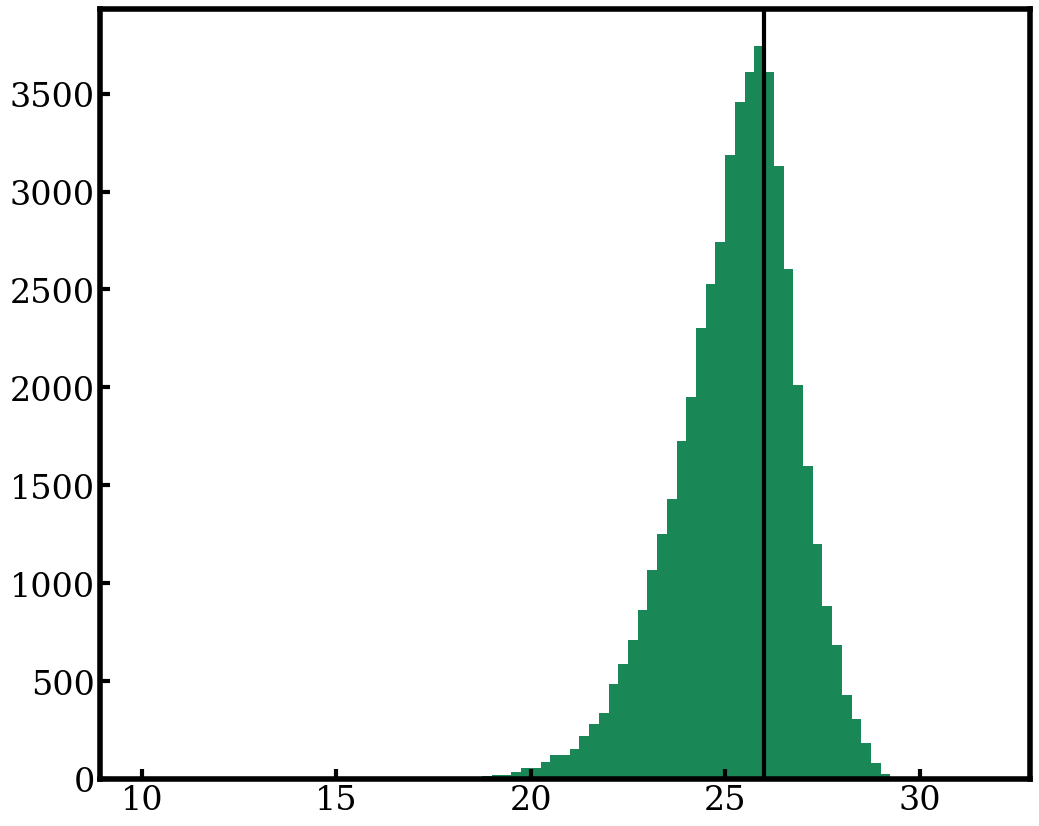

In [21]:
fig = plt.figure()
ax = fig.add_subplot()

bins = np.arange(10, 32, 0.25)
ax.hist(PHOTOMETRY_WideFastDeep_noisy["LSST_i"], bins = bins)
ax.axvline(26, color = "black")

Text(0, 0.5, '$g-r$')

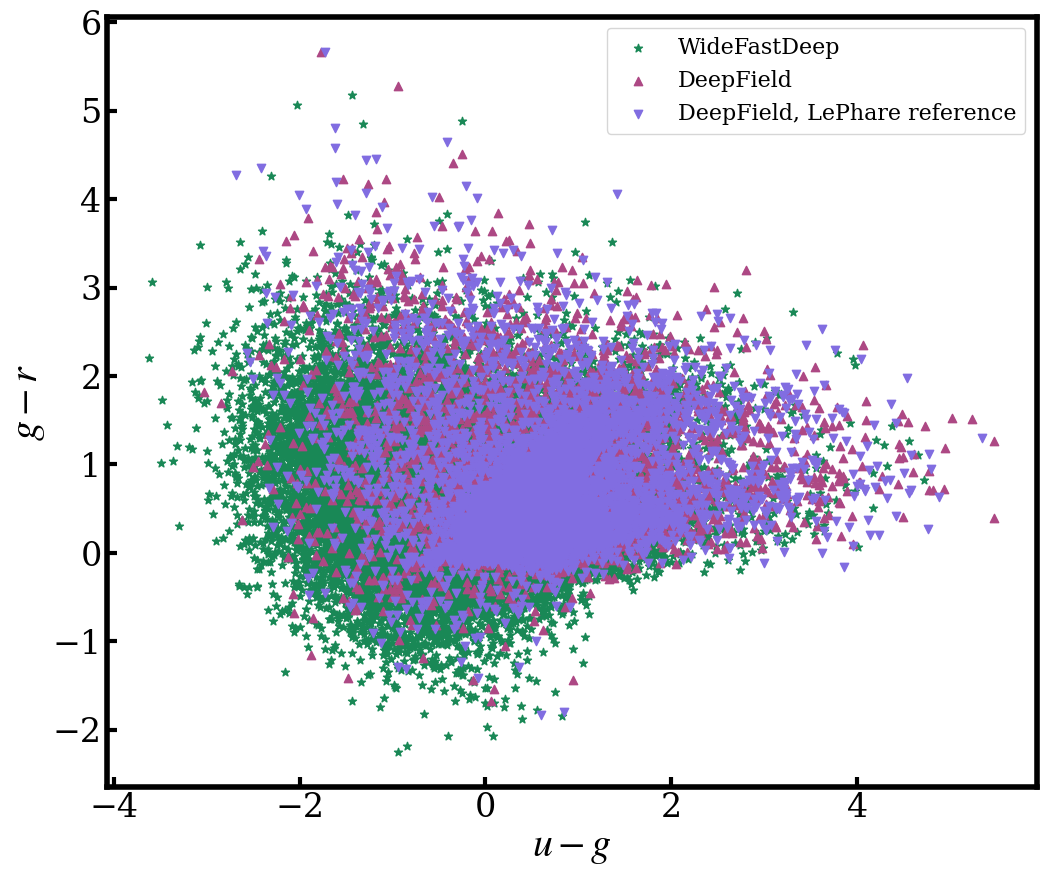

In [30]:
fig = plt.figure()
ax = fig.add_subplot()

iBandLimit_DeepField    = 27.5
iBandLimit_WideFastDeep = 25

ax.scatter(PHOTOMETRY_WideFastDeep_noisy["LSST_u"] - PHOTOMETRY_WideFastDeep_noisy["LSST_g"],
           PHOTOMETRY_WideFastDeep_noisy["LSST_g"] - PHOTOMETRY_WideFastDeep_noisy["LSST_r"],
           marker = '*', label = "WideFastDeep")

ax.scatter(PHOTOMETRY_DeepField_noisy["LSST_u"] - PHOTOMETRY_DeepField_noisy["LSST_g"],
           PHOTOMETRY_DeepField_noisy["LSST_g"] - PHOTOMETRY_DeepField_noisy["LSST_r"],
           marker = '^', label = "DeepField")

ax.scatter(PHOTOMETRY_DeepField_noisy_lpReference["LSST_u"] - PHOTOMETRY_DeepField_noisy_lpReference["LSST_g"],
           PHOTOMETRY_DeepField_noisy_lpReference["LSST_g"] - PHOTOMETRY_DeepField_noisy_lpReference["LSST_r"],
           marker = 'v', label = "DeepField, LePhare reference")

ax.legend(loc = "upper right", fontsize = 16)
ax.set_xlabel("$u-g$")
ax.set_ylabel("$g-r$")

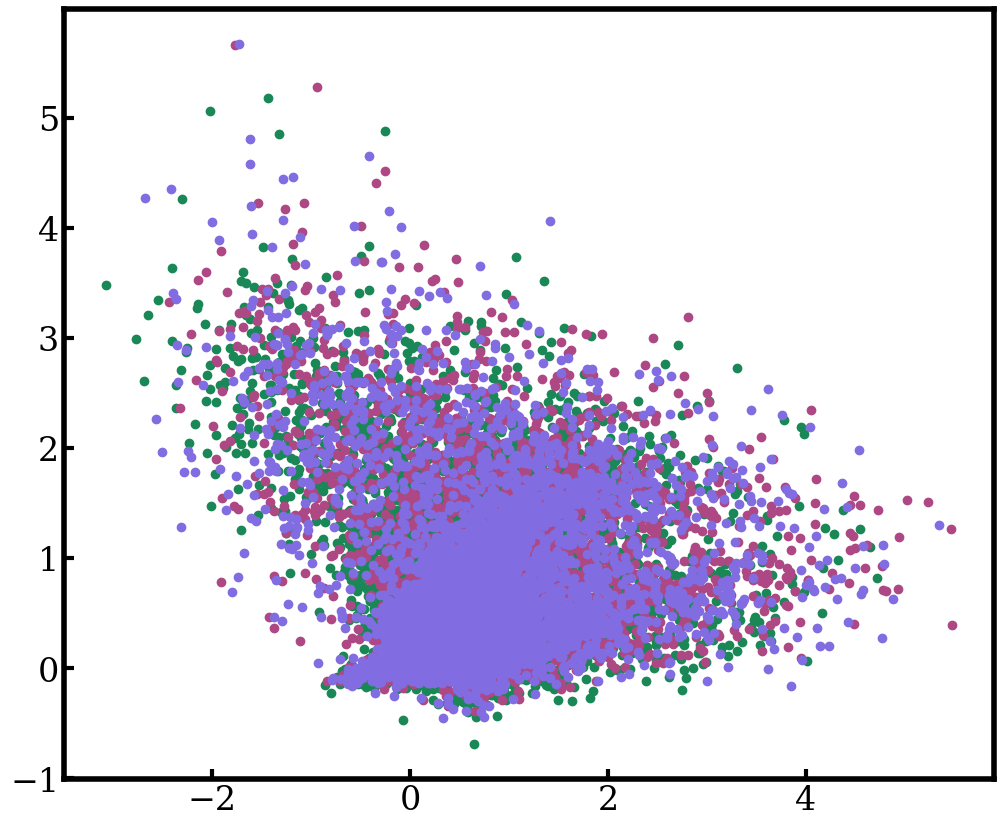

In [13]:
fig = plt.figure()
ax = fig.add_subplot()

iBandLimit_DeepField    = 27.5
iBandLimit_WideFastDeep = 25

ax.scatter(PHOTOMETRY_WideFastDeep_noisy[PHOTOMETRY_WideFastDeep_noisy["LSST_i"] < iBandLimit_WideFastDeep]["LSST_u"] - PHOTOMETRY_WideFastDeep_noisy[PHOTOMETRY_WideFastDeep_noisy["LSST_i"] < iBandLimit_WideFastDeep]["LSST_g"],
           PHOTOMETRY_WideFastDeep_noisy[PHOTOMETRY_WideFastDeep_noisy["LSST_i"] < iBandLimit_WideFastDeep]["LSST_g"] - PHOTOMETRY_WideFastDeep_noisy[PHOTOMETRY_WideFastDeep_noisy["LSST_i"] < iBandLimit_WideFastDeep]["LSST_r"])

ax.scatter(PHOTOMETRY_DeepField_noisy[PHOTOMETRY_DeepField_noisy["LSST_i"] < iBandLimit_DeepField]["LSST_u"] - PHOTOMETRY_DeepField_noisy[PHOTOMETRY_DeepField_noisy["LSST_i"] < iBandLimit_DeepField]["LSST_g"],
           PHOTOMETRY_DeepField_noisy[PHOTOMETRY_DeepField_noisy["LSST_i"] < iBandLimit_DeepField]["LSST_g"] - PHOTOMETRY_DeepField_noisy[PHOTOMETRY_DeepField_noisy["LSST_i"] < iBandLimit_DeepField]["LSST_r"])

ax.scatter(PHOTOMETRY_DeepField_noisy_lpReference[PHOTOMETRY_DeepField_noisy_lpReference["LSST_i"] < iBandLimit_DeepField]["LSST_u"] - PHOTOMETRY_DeepField_noisy_lpReference[PHOTOMETRY_DeepField_noisy_lpReference["LSST_i"] < iBandLimit_DeepField]["LSST_g"],
           PHOTOMETRY_DeepField_noisy_lpReference[PHOTOMETRY_DeepField_noisy_lpReference["LSST_i"] < iBandLimit_DeepField]["LSST_g"] - PHOTOMETRY_DeepField_noisy_lpReference[PHOTOMETRY_DeepField_noisy_lpReference["LSST_i"] < iBandLimit_DeepField]["LSST_r"])


(array([ 55., 147., 195., 232., 284., 310., 407., 451., 495., 507., 564.,
        524., 486., 479., 380., 388., 346., 309., 253., 226., 248., 206.,
        183., 173., 171., 139., 103., 126., 101.,  86.,  88.,  83.,  95.,
         83.,  66.,  69.,  75.,  43.,  62.,  70.,  52.,  66.,  55.,  64.,
         57.,  50.,  48.,  37.,  33.,  29.,  33.,  23.,  23.,  23.,  14.,
         18.,  16.,  14.,  21.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. , 1.1, 1.2,
        1.3, 1.4, 1.5, 1.6, 1.7, 1.8, 1.9, 2. , 2.1, 2.2, 2.3, 2.4, 2.5,
        2.6, 2.7, 2.8, 2.9, 3. , 3.1, 3.2, 3.3, 3.4, 3.5, 3.6, 3.7, 3.8,
        3.9, 4. , 4.1, 4.2, 4.3, 4.4, 4.5, 4.6, 4.7, 4.8, 4.9, 5. , 5.1,
        5.2, 5.3, 5.4, 5.5, 5.6, 5.7, 5.8, 5.9]),
 [<matplotlib.patches.Polygon at 0x7ef9de0a6f90>])

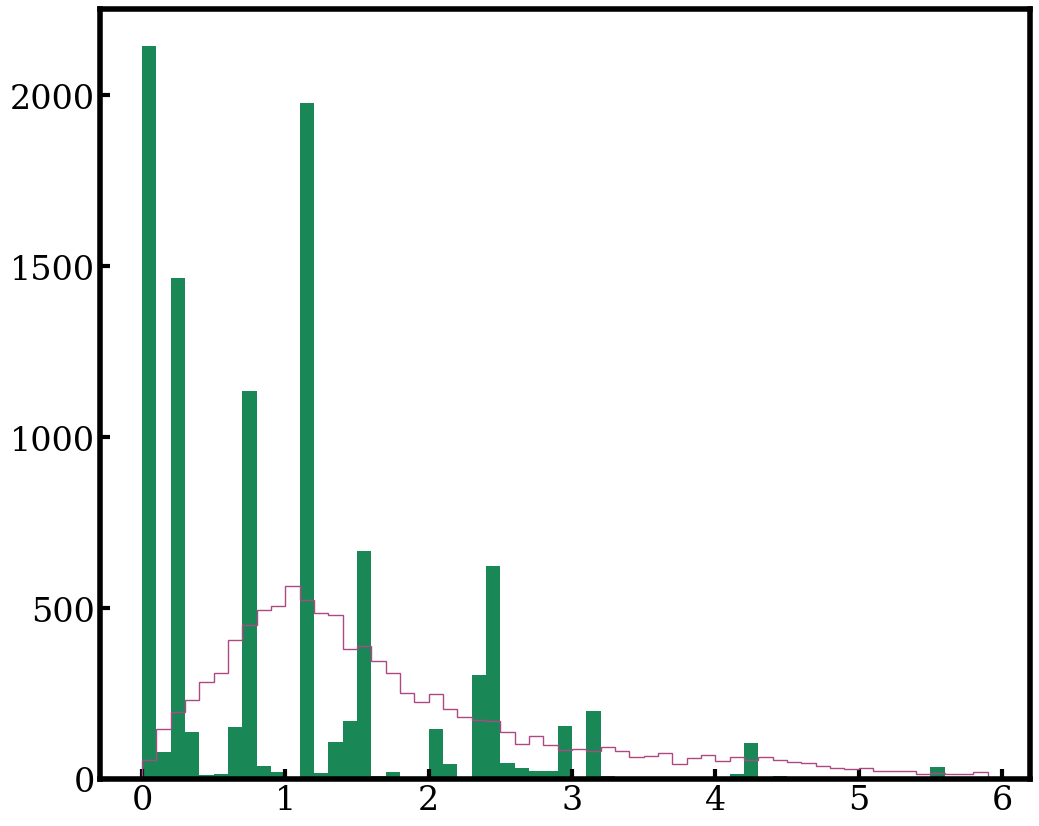

In [12]:
fig = plt.figure()
ax = fig.add_subplot()

bins = np.arange(0, 6, 0.1)

ax.hist(PHOTOZS_DeepField_lePhare, bins = bins)
ax.hist(REDSHIFTS_DeepField, histtype = 'step', bins = bins)

In [7]:
PHOTOZS_DeepField_lePhare['photo-z']

0       0.704333
1       0.700965
2       1.500211
3       0.702051
4       1.513744
          ...   
9995    1.130653
9996    0.049415
9997    1.124912
9998    0.820370
9999    0.025757
Name: photo-z, Length: 10000, dtype: float64

In [ ]:
REDSHIFTS_WideFastDeep = np.load(f"{outputs_directory}/TRUEREDSHIFTS_WideFastDeep.npy")
PHOTOZS_estimated_wSpecZs = tables_io.read(f"{outputs_directory}/estimatedPhotoZMedians_UMAP_wSpecZs_08Jul26.pq")
PHOTOZS_estimated_wPhotoZs = tables_io.read(f"{outputs_directory}/estimatedPhotoZMedians_UMAP_wPhotoZs_08Jul26.pq")